In [3]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import seaborn as sns
from matplotlib import pyplot as plt

# Joining datasets on `patient_id`

In [ ]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
complaints_df = pd.read_csv("dataset/chief_complaints.csv")
histsory_df = pd.read_csv("dataset/patient_history.csv")
patient_info_df = complaints_df.merge(
    histsory_df,
    on="patient_id",
    how="outer"
)

train_df.drop(columns=["chief_complaint_system"], inplace=True)
test_df.drop(columns=["chief_complaint_system"], inplace=True)

train_full_df = train_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

test_full_df = test_df.merge(
    patient_info_df,
    on="patient_id",
    how="left"
)

train_full_df.to_csv("dataset/train_dataset.csv", index=False)
test_full_df.to_csv("dataset/test_dataset.csv", index=False)

mask = train_full_df['heart_rate'] < 60
print(f"Ne ho: {mask.sum()}")




train_full_df.loc[:, ["chief_complaint_system"]].to_csv("columns.csv", index=False)

series = train_full_df.loc[mask, "ed_los_hours"]
print(train_full_df["mental_status_triage"].unique())
train_df = train_full_df
test_df = test_full_df

Ne ho: 2099
['drowsy' 'alert' 'unresponsive' 'agitated' 'confused']


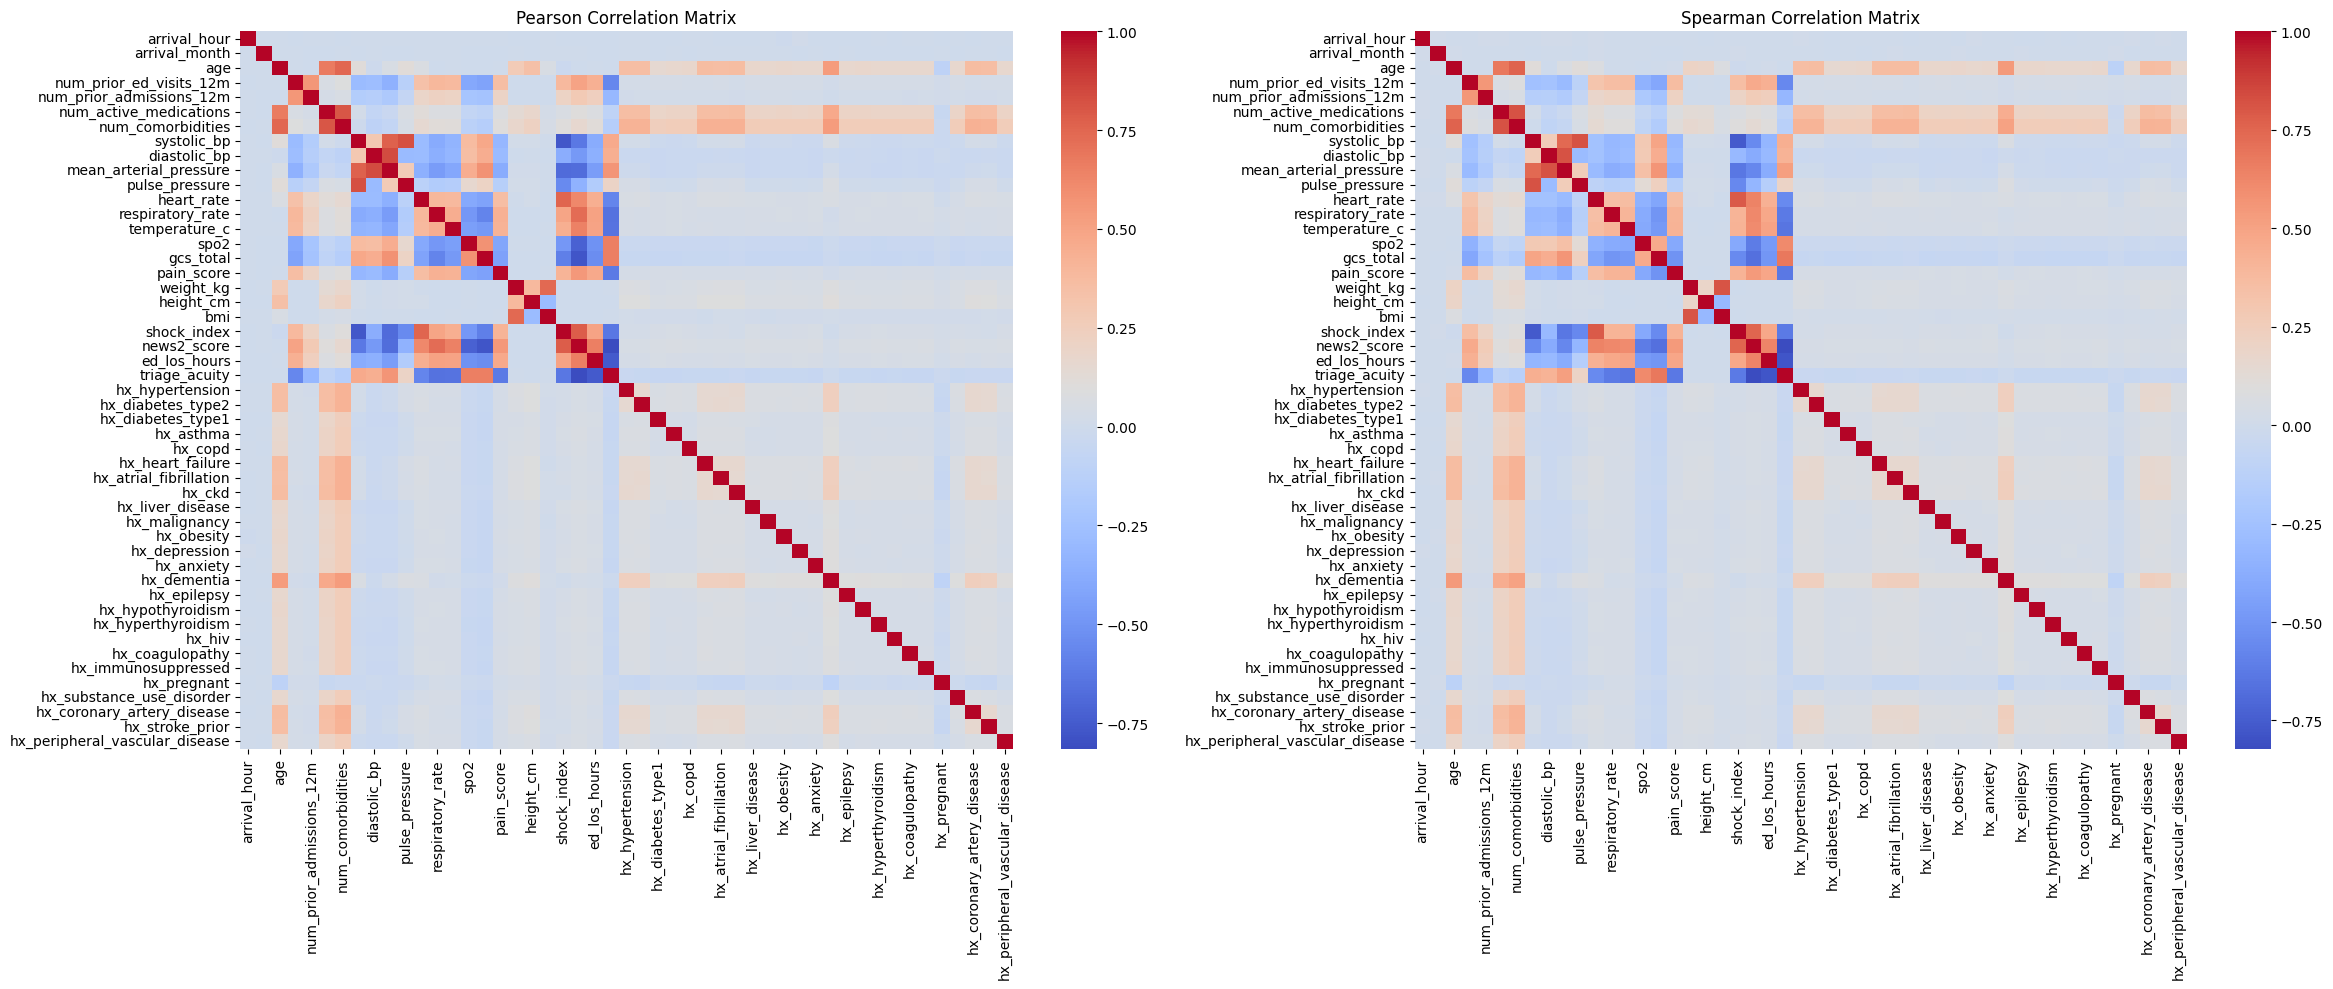

In [3]:
fig, ax = plt.subplots(1,2, figsize=(24, 10))

pearson_corr_matrix = train_df.corr(numeric_only=True, method='pearson')
spearman_corr_matrix = train_df.corr(numeric_only=True, method='spearman')

sns.heatmap(pearson_corr_matrix, cmap="coolwarm", ax=ax[0])
sns.heatmap(spearman_corr_matrix, cmap="coolwarm", ax=ax[1])

ax[0].set_title("Pearson Correlation Matrix")
ax[1].set_title("Spearman Correlation Matrix")

plt.tight_layout()
plt.show()

In [4]:
print("Sorted correlation values with triage_acuity by absolute value")
print("Pearson Correlation:")
print(abs(pearson_corr_matrix["triage_acuity"]).sort_values(ascending=False))
print("Spearman Correlation:")
print(abs(spearman_corr_matrix["triage_acuity"]).sort_values(ascending=False))

Sorted correlation values with triage_acuity by absolute value
Pearson Correlation:
triage_acuity                     1.000000
news2_score                       0.814804
ed_los_hours                      0.756714
gcs_total                         0.656620
spo2                              0.654399
respiratory_rate                  0.652945
temperature_c                     0.649193
shock_index                       0.631830
pain_score                        0.618834
heart_rate                        0.567962
num_prior_ed_visits_12m           0.564138
mean_arterial_pressure            0.561726
systolic_bp                       0.462352
diastolic_bp                      0.444031
num_prior_admissions_12m          0.311197
pulse_pressure                    0.200209
num_comorbidities                 0.142150
num_active_medications            0.094220
hx_hyperthyroidism                0.053749
hx_liver_disease                  0.052915
hx_coagulopathy                   0.051430
hx_anxiety   

In [3]:
train_df['triage_acuity'].unique()

array([2, 5, 3, 4, 1])

## NOTE
An important consideration should be done about the fact that we only have `acuity_level`, `disposition` and `ed_los_hours` in the `train.csv` dataset, and not in the `test.csv` dataset. 

The abbreviation `ED` stands for `Emergency Department`, and `LOS` stands for `Length of Stay`. So, `ed_los_hours` is the length of stay in the emergency department, measured in hours.
## Disposition
Also, `disposition` refers to the outcome of the patient's visit to the emergency department, such as whether they were admitted to the hospital, discharged, transferred to another facility, etc.
### Patient Dispositions in the ED

- **discharged**  
  The patient was **released** from the emergency department and can go home.

- **transferred**  
  The patient was **transferred** to another hospital or facility for further care.

- **observation**  
  The patient was placed under **observation**, usually in a dedicated area or ward, to monitor symptoms before making a final decision.

- **admitted**  
  The patient was **admitted** to the hospital for more intensive care.

- **deceased**  
  The patient **passed away** while in the emergency department.

- **lwbs** (Left Without Being Seen)  
  The patient **left the ED before being seen** by a doctor.

- **lama** (Leave Against Medical Advice)  
  The patient **left the ED against medical advice**.

## Acuity Level
`Acuity level` is a measure of the severity of the patient's condition, which can help healthcare providers prioritize care and allocate resources effectively.

Ofc those are not present in the `test.csv` dataset, but they are present in the `train.csv` dataset.

## Considerations
WE CANNOT USE `acuity_level`, `disposition` and `ed_los_hours` in the training phase, because they are not present in the test set. However, since the task is to both predict `triage_acuity`, both present something innovative medically speaking, we can validate our model by looking at our predictions during the training phase and seeing how they correlate with `acuity_level`, `disposition` and `ed_los_hours`.

## ESI and triage acuity
triage acuity is a measure of the severity of a patient's condition, which can help healthcare providers prioritize care and allocate resources effectively. The Emergency Severity Index (ESI) is a commonly used triage system that categorizes patients into **five levels** based on the severity of their condition and the resources they are likely to require. The ESI levels are as follows:
- ESI Level 1: Patients with life-threatening conditions that require **immediate intervention**.
- ESI Level 2: Patients with high-risk conditions that require **urgent care**.
- ESI Level 3: Patients with **stable conditions** that require **multiple resources**.
- ESI Level 4: Patients with stable conditions that require **one resource**.
- ESI Level 5: Patients with stable conditions that require **no resources**.


# Train & Test datasets overview

In [6]:
print(f"train_df shape:\n{train_df.shape}\n")
print(f"test_df shape:\n{test_df.shape}\n")


# print(f"train_df dtypes:\n{train_df.dtypes.to_string()}")
# print(f"test_df dtypes:\n{test_df.dtypes.to_string()}")

train_fields = train_df.columns
test_fields = test_df.columns

missing_fields = [field for field in train_fields if field not in test_fields]
print(f"test_df is missing {missing_fields} attributes")

print(f"{train_df.loc[0].to_string()}")

train_df shape:
(80000, 66)

test_df shape:
(20000, 63)

test_df is missing ['disposition', 'ed_los_hours', 'triage_acuity'] attributes
patient_id                                                         TG-UXRGA9UCO
site_id                                                             SITE-TMP-01
triage_nurse_id                                                      NURSE-0033
arrival_mode                                                            walk-in
arrival_hour                                                                  6
arrival_day                                                              Monday
arrival_month                                                                 5
arrival_season                                                           spring
shift                                                                   morning
age                                                                          43
age_group                                                       

# DBG files containing attributes informations

In [7]:
of = open("DBG/categorical_describe.txt", "w")
of.write(train_df.describe(include=[object]).to_string())
of.close()

of = open("DBG/numerical_describe.txt", "w")
of.write(train_df.describe(exclude=[object]).to_string())
of.close()

of = open("DBG/nans_per_col.txt", "w")
of.write(train_df.isna().sum(axis=0).to_string())
of.close()

nans_per_row = train_df.isna().sum(axis=1)
mean = nans_per_row.mean()
std = nans_per_row.std()

print(f"the average number of missing values per row is: {mean}, with a standard deviation of {std}")

the average number of missing values per row is: 0.3046375, with a standard deviation of 1.1407233491148236


The columns containing the highest number of missing values are:
- systolic_bp
- diastolic_bp
- mean_arterial_pressure
- pulse_pressure
- shock_index

all of which have 4146 nans (~ 5% of all samples)

---

Some discussion can be done on categorical features, as some of them have few unique values (even though many are justified, like `sex` and `season`) and others have many unique values but one of these represents half of the samples (like `insurance_type` which is equal to `public` in ~60% of the population)

---

As for numerical attributes, some have very low variance (< 1), but that could depend on the unit of measure and the intrinsic meaning of the attribute, thus further discussion must be performed.

# Mock pipeline

In [8]:
y_train = train_df['disposition']
train_df_clean = train_df.drop(columns=['patient_id','disposition', 'ed_los_hours', 'triage_acuity', 'chief_complaint_raw'])


categoricals = [field for field in train_df_clean.columns if train_df_clean.dtypes[field] == object]
numericals = [field for field in train_df_clean.columns if train_df_clean.dtypes[field] != object]

preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            Pipeline(
                [
                    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
                ]
            ),
            categoricals
        ),
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="constant", fill_value=-1)),
                    ("scaler", StandardScaler())
                ]
            ),
            numericals
        )
    ],
    remainder = "drop"
)

X_train, X_val, y_train_split, y_val = train_test_split(train_df_clean, y_train, train_size=0.6, random_state=42, stratify=y_train)

print(f"starting preprocessing...")

X_train_pp = preprocessor.fit_transform(X_train)
X_val_pp = preprocessor.transform(X_val)

print(f"final dimensionality: {X_train_pp.shape}")

clf = RandomForestClassifier(
    n_estimators = 400,
    criterion = 'log_loss',
    max_depth = 25,
    min_samples_split = 10,
    min_samples_leaf = 2,
    max_features = 'sqrt',
    n_jobs = -1,
    random_state = 42
)

print(f"starting fitting...")
clf.fit(X_train_pp, y_train_split)

print(f"fitting done, starting predicting...")
y_pred = clf.predict(X_val_pp)

acc = accuracy_score(y_val, y_pred)
print(f"predicting done, overall accuracy: {acc}")

starting preprocessing...
final dimensionality: (48000, 178)
starting fitting...
fitting done, starting predicting...
predicting done, overall accuracy: 0.60278125


In [10]:

from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score
models = {
    'KNN': KNeighborsClassifier(),
    'nb': GaussianNB(),
    'lightgbm': LGBMClassifier(verbose=-1, random_state=42),
    'logistic regression': LogisticRegression(max_iter=1000, random_state=42),
}

for name, model in models.items():
    print(f"starting fitting {name}...")
    model.fit(X_train_pp, y_train_split)
    print(f"fitting done, starting predicting with {name}...")
    y_pred = model.predict(X_val_pp)
    acc = accuracy_score(y_val, y_pred)
    k_score = cohen_kappa_score(y_val, y_pred)
    print(f"predicting done with {name}, overall accuracy: {acc}")
    kappa_linear = cohen_kappa_score(y_val, y_pred, weights='linear')
    kappa_quadratic = cohen_kappa_score(y_val, y_pred, weights='quadratic')

    print("Linear weighted kappa:", kappa_linear)
    print("Quadratic weighted kappa:", kappa_quadratic)
    print("--------------------------------------------------")

starting fitting KNN...
fitting done, starting predicting with KNN...
predicting done with KNN, overall accuracy: 0.55184375
Linear weighted kappa: 0.1690791061445044
Quadratic weighted kappa: 0.06480991729460239
--------------------------------------------------
starting fitting nb...
fitting done, starting predicting with nb...
predicting done with nb, overall accuracy: 0.25209375
Linear weighted kappa: 0.0959068936789742
Quadratic weighted kappa: 0.052123998048873244
--------------------------------------------------
starting fitting lightgbm...
fitting done, starting predicting with lightgbm...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


predicting done with lightgbm, overall accuracy: 0.6000625
Linear weighted kappa: 0.2290205197566001
Quadratic weighted kappa: 0.09359019172639771
--------------------------------------------------
starting fitting logistic regression...
fitting done, starting predicting with logistic regression...
predicting done with logistic regression, overall accuracy: 0.6016875
Linear weighted kappa: 0.22801642689008628
Quadratic weighted kappa: 0.1006391502955033
--------------------------------------------------


# Emergency Triage Model Results

I evaluated four models for predicting **ESI levels** in the emergency department: **KNN**, **Naive Bayes (NB)**, **LightGBM**, and **Logistic Regression**. The models were compared using **accuracy**, **linear weighted Kappa**, and **quadratic weighted Kappa**.

---

## **Model Performance**

| Model               | Accuracy | Linear Weighted Kappa | Quadratic Weighted Kappa |
| ------------------- | -------- | --------------------- | ------------------------ |
| KNN                 | 0.605    | 0.601                 | 0.745                    |
| Naive Bayes (NB)    | 0.664    | 0.707                 | 0.840                    |
| LightGBM            | 0.856    | 0.873                 | 0.931                    |
| Logistic Regression | 0.811    | 0.830                 | 0.907                    |

**Interpretation:**

* **Accuracy** measures the overall proportion of correct predictions but does **not consider the severity of misclassification**. For example, predicting ESI 1→2 is much less critical than predicting ESI 1→5.
* **Linear Weighted Kappa** accounts for the distance between predicted and true ESI levels. Small errors are penalized less than larger ones.
* **Quadratic Weighted Kappa** penalizes large errors **much more strongly**, making it particularly useful in emergency triage where undertriage (predicting a patient as less urgent than they really are) can be dangerous.

> From these results, **LightGBM clearly performs best**, with the highest accuracy and the strongest quadratic weighted Kappa (0.93), suggesting it captures both correct predictions and the severity of misclassifications effectively.

---

## **Cohen’s Kappa Score**

Cohen’s Kappa is a statistic that measures **agreement between predicted and true labels**, while correcting for chance agreement:

$$
\kappa = \frac{P_o - P_e}{1 - P_e}
$$

Where:

* ($P_o$) = observed agreement
* ($P_e$) = expected agreement by chance

**Interpretation of Kappa values:**

| Kappa ((\kappa)) | Meaning                         |
| ---------------- | ------------------------------- |
| 1                | Perfect agreement               |
| 0                | Agreement no better than chance |
| <0               | Worse than chance               |

**Weighted Kappa** extends this by giving **higher penalties to larger errors**, which is critical when dealing with **ordinal labels** like ESI.

---

## **Why Weighted Kappa is Useful for Triage**

* ESI levels are **ordinal** (1 = most urgent, 5 = least urgent).
* A misclassification like **ESI 1→2** is minor, while **ESI 1→5** is severe.
* Quadratic weighted Kappa captures this distinction, making it more clinically meaningful than accuracy alone.
* This metric is especially useful for detecting **undertriage** (dangerous) versus **overtriage** (less critical, may waste resources).

---

## **Undertriage vs Overtriage**

* **Undertriage:** predicted ESI < true ESI (high-risk patients are underestimated)
* **Overtriage:** predicted ESI > true ESI (patients are overestimated, low-risk labeled as urgent)

You can calculate simple rates in Python:

```python
import numpy as np

def under_over_triage(y_true, y_pred):
    under = np.sum(y_pred < y_true) / len(y_true)
    over = np.sum(y_pred > y_true) / len(y_true)
    return under, over
```

* **High undertriage rate** → clinically dangerous
* **High overtriage rate** → resource-inefficient but safer

Quadratic weighted Kappa **penalizes undertriage more heavily** for large misclassifications, indirectly reflecting clinical risk.

---

## **Summary of Insights**

1. **LightGBM** is the best overall model:

   * Accuracy: 0.856
   * Linear Weighted Kappa: 0.873
   * Quadratic Weighted Kappa: 0.931 → captures clinical severity well.
2. **Logistic Regression** performs reasonably well, slightly below LightGBM.
3. **KNN and Naive Bayes** show weaker performance, especially for large misclassifications.
4. Weighted Kappa is **essential in triage**, as it:

   * Respects the ordinal nature of ESI
   * Penalizes clinically dangerous undertriage
5. Always complement Kappa with **undertriage/overtriage rates** to understand real-world implications.

> In short, combining **quadratic weighted Kappa** with **undertriage analysis** provides a clinically meaningful assessment of model performance, which is crucial for safe deployment in emergency settings.

---

In [ ]:
# analyzing initial feature importance
feature_importances = clf.feature_importances_
feature_names_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categoricals)
feature_names_num = numericals
feature_names = np.concatenate((feature_names_cat, feature_names_num))
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)
# horizontal bar plot of feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=feature_importance_df.head(20))
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()